**Cell 1: setup, exact solution, residual check**

In [1]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt, copy
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print(dev)

RE = 40.0
LAM = RE/2 - np.sqrt(RE**2/4 + 4*np.pi**2)

def exact(x, y):
    """Kovasznay analytical solution (torch tensors)."""
    e = torch.exp(LAM*x)
    u = 1 - e*torch.cos(2*np.pi*y)
    v = LAM/(2*np.pi)*e*torch.sin(2*np.pi*y)
    p = 0.5*(1 - e**2)
    return u, v, p

def g(f, z):
    """df/dz via autograd; zeros if f doesn't depend on z."""
    out = torch.autograd.grad(f, z, torch.ones_like(f),
                              create_graph=True, allow_unused=True)[0]
    return torch.zeros_like(f) if out is None else out

def ns_residual(u, v, p, x, y):
    """Continuity, x-momentum, y-momentum residuals."""
    u_x, u_y = g(u, x), g(u, y)
    v_x, v_y = g(v, x), g(v, y)
    p_x, p_y = g(p, x), g(p, y)
    u_xx, u_yy = g(u_x, x), g(u_y, y)
    v_xx, v_yy = g(v_x, x), g(v_y, y)
    r_c = u_x + v_y
    r_u = u*u_x + v*u_y + p_x - (u_xx + u_yy)/RE
    r_v = u*v_x + v*v_y + p_y - (v_xx + v_yy)/RE
    return r_c, r_u, r_v

# Sanity check: exact solution should give ~0 residual
x = (torch.rand(1000, 1)*1.5 - 0.5).requires_grad_(True)
y = (torch.rand(1000, 1)*2.0 - 0.5).requires_grad_(True)
u, v, p = exact(x, y)
rs = ns_residual(u, v, p, x, y)
print("lambda =", LAM)
print("max |residual| (c, u, v):", [f"{r.abs().max().item():.2e}" for r in rs])

cuda
lambda = -0.9637405441957689
max |residual| (c, u, v): ['2.38e-07', '8.34e-07', '7.45e-08']


**Cell 2: the multi-output network and sampling**

In [2]:
torch.manual_seed(0)

class PINN(nn.Module):
    def __init__(self, hidden=40, layers=6):
        super().__init__()
        dims = [2] + [hidden]*layers + [3]          # (x,y) -> (u,v,p)
        self.lins = nn.ModuleList([nn.Linear(a, b) for a, b in zip(dims[:-1], dims[1:])])
        for l in self.lins:
            nn.init.xavier_normal_(l.weight); nn.init.zeros_(l.bias)
    def forward(self, x, y):
        h = torch.cat([x, y], dim=1)
        for l in self.lins[:-1]:
            h = torch.tanh(l(h))
        out = self.lins[-1](h)
        return out[:, 0:1], out[:, 1:2], out[:, 2:3]   # u, v, p

model = PINN().to(dev)
print("params:", sum(p.numel() for p in model.parameters()))

X0, X1, Y0, Y1 = -0.5, 1.0, -0.5, 1.5
def rnd(n, a, b): return torch.rand(n, 1, device=dev)*(b - a) + a

# Collocation points (interior)
x_f = rnd(5000, X0, X1).requires_grad_(True)
y_f = rnd(5000, Y0, Y1).requires_grad_(True)

# Boundary points: 100 on each of the 4 edges
n = 100
x_b = torch.cat([rnd(n, X0, X1), rnd(n, X0, X1),
                 torch.full((n, 1), X0, device=dev), torch.full((n, 1), X1, device=dev)])
y_b = torch.cat([torch.full((n, 1), Y0, device=dev), torch.full((n, 1), Y1, device=dev),
                 rnd(n, Y0, Y1), rnd(n, Y0, Y1)])
with torch.no_grad():
    u_b, v_b, _ = exact(x_b, y_b)

# Pressure anchor at the domain corner (x=1, y=0)
x_a = torch.tensor([[1.0]], device=dev); y_a = torch.tensor([[0.0]], device=dev)
with torch.no_grad():
    p_a = exact(x_a, y_a)[2]

# Quick check: untrained network outputs and residual shapes
u, v, p = model(x_f, y_f)
rs = ns_residual(u, v, p, x_f, y_f)
print("output shapes:", u.shape, v.shape, p.shape)
print("initial residual MSE (c,u,v):", [f"{(r**2).mean().item():.2e}" for r in rs])

params: 8443
output shapes: torch.Size([5000, 1]) torch.Size([5000, 1]) torch.Size([5000, 1])
initial residual MSE (c,u,v): ['1.65e-01', '2.22e-02', '5.88e-02']


**Cell 3: loss and training**

In [3]:
W_PDE, W_BC, W_P = 1.0, 10.0, 10.0

def losses():
    u, v, p = model(x_f, y_f)
    r_c, r_u, r_v = ns_residual(u, v, p, x_f, y_f)
    l_pde = (r_c**2).mean() + (r_u**2).mean() + (r_v**2).mean()
    ub, vb, _ = model(x_b, y_b)
    l_bc = ((ub - u_b)**2).mean() + ((vb - v_b)**2).mean()
    _, _, pa = model(x_a, y_a)
    l_p = ((pa - p_a)**2).mean()
    return l_pde, l_bc, l_p

# Validation grid + metric
xs = torch.linspace(X0, X1, 100, device=dev); ys = torch.linspace(Y0, Y1, 100, device=dev)
XG, YG = torch.meshgrid(xs, ys, indexing='xy')
xg, yg = XG.reshape(-1, 1), YG.reshape(-1, 1)
with torch.no_grad():
    ue, ve, pe = exact(xg, yg)

def rel_l2():
    with torch.no_grad():
        u, v, p = model(xg, yg)
    f = lambda a, b: ((a - b).norm() / b.norm()).item()
    return f(u, ue), f(v, ve), f(p, pe)

# Stage 1: Adam
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sch = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9997)
hist = []
for it in range(10001):
    opt.zero_grad()
    l_pde, l_bc, l_p = losses()
    loss = W_PDE*l_pde + W_BC*l_bc + W_P*l_p
    loss.backward(); opt.step(); sch.step()
    hist.append([loss.item(), l_pde.item(), l_bc.item(), l_p.item()])
    if it % 1000 == 0:
        print(f"{it:5d} loss {loss.item():.2e} pde {l_pde.item():.2e} "
              f"bc {l_bc.item():.2e} p {l_p.item():.2e} relL2(u,v,p) "
              + " ".join(f"{e:.4f}" for e in rel_l2()))
model_adam = copy.deepcopy(model)

# Stage 2: L-BFGS (fixed points)
opt2 = torch.optim.LBFGS(model.parameters(), lr=1, max_iter=1000,
                         history_size=50, line_search_fn='strong_wolfe')
def closure():
    opt2.zero_grad()
    l_pde, l_bc, l_p = losses()
    loss = W_PDE*l_pde + W_BC*l_bc + W_P*l_p
    loss.backward()
    return loss
opt2.step(closure)
l_pde, l_bc, l_p = losses()
print(f"after L-BFGS: pde {l_pde.item():.2e} bc {l_bc.item():.2e} p {l_p.item():.2e}")
print("final relL2 (u,v,p):", [f"{e:.2e}" for e in rel_l2()])

    0 loss 3.15e+01 pde 2.46e-01 bc 2.76e+00 p 3.69e-01 relL2(u,v,p) 0.9115 1.4823 0.9604
 1000 loss 2.71e-01 pde 7.12e-02 bc 2.00e-02 p 8.91e-08 relL2(u,v,p) 0.1287 0.3956 0.1815
 2000 loss 4.81e-02 pde 2.54e-02 bc 2.28e-03 p 2.70e-08 relL2(u,v,p) 0.0536 0.1501 0.0920
 3000 loss 2.84e-02 pde 1.57e-02 bc 1.27e-03 p 3.62e-09 relL2(u,v,p) 0.0368 0.1055 0.0829
 4000 loss 1.83e-02 pde 1.12e-02 bc 7.18e-04 p 1.49e-12 relL2(u,v,p) 0.0295 0.0888 0.0720
 5000 loss 1.22e-02 pde 8.07e-03 bc 4.17e-04 p 1.28e-13 relL2(u,v,p) 0.0225 0.0756 0.0677
 6000 loss 8.61e-03 pde 5.92e-03 bc 2.68e-04 p 1.69e-11 relL2(u,v,p) 0.0180 0.0673 0.0626
 7000 loss 6.33e-03 pde 4.47e-03 bc 1.86e-04 p 1.55e-11 relL2(u,v,p) 0.0147 0.0589 0.0553
 8000 loss 4.76e-03 pde 3.44e-03 bc 1.32e-04 p 6.51e-10 relL2(u,v,p) 0.0120 0.0503 0.0476
 9000 loss 3.63e-03 pde 2.68e-03 bc 9.46e-05 p 4.48e-12 relL2(u,v,p) 0.0097 0.0426 0.0405
10000 loss 2.81e-03 pde 2.12e-03 bc 6.88e-05 p 5.27e-12 relL2(u,v,p) 0.0080 0.0365 0.0345
after L-BF

**Cell 4: diagnose L-BFGS, continue Adam, retry L-BFGS**

In [4]:
# 1) Investigating Why the first L-BFGS stoped
st = opt2.state[opt2._params[0]]
print("first L-BFGS: n_iter", st['n_iter'], "func_evals", st['func_evals'])

# 2) Continue Adam with a fresh optimizer, smaller lr
opt = torch.optim.Adam(model.parameters(), lr=5e-4)
sch = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9997)
for it in range(10001):
    opt.zero_grad()
    l_pde, l_bc, l_p = losses()
    loss = W_PDE*l_pde + W_BC*l_bc + W_P*l_p
    loss.backward(); opt.step(); sch.step()
    hist.append([loss.item(), l_pde.item(), l_bc.item(), l_p.item()])
    if it % 2000 == 0:
        print(f"{it:5d} loss {loss.item():.2e} pde {l_pde.item():.2e} "
              f"bc {l_bc.item():.2e} relL2(u,v,p) "
              + " ".join(f"{e:.4f}" for e in rel_l2()))
model_adam2 = copy.deepcopy(model)

# 3) L-BFGS again, loosened tolerances
opt3 = torch.optim.LBFGS(model.parameters(), lr=1, max_iter=1000, history_size=50,
                         tolerance_grad=1e-12, tolerance_change=1e-14,
                         line_search_fn='strong_wolfe')
def closure3():
    opt3.zero_grad()
    l_pde, l_bc, l_p = losses()
    loss = W_PDE*l_pde + W_BC*l_bc + W_P*l_p
    loss.backward()
    return loss
opt3.step(closure3)
st = opt3.state[opt3._params[0]]
print("second L-BFGS: n_iter", st['n_iter'], "func_evals", st['func_evals'])
l_pde, l_bc, l_p = losses()
print(f"final: pde {l_pde.item():.2e} bc {l_bc.item():.2e} p {l_p.item():.2e}")
print("final relL2 (u,v,p):", [f"{e:.2e}" for e in rel_l2()])

first L-BFGS: n_iter 1 func_evals 5
    0 loss 2.81e-03 pde 2.12e-03 bc 6.88e-05 relL2(u,v,p) 0.5372 0.6806 0.0686
 2000 loss 2.10e-03 pde 1.62e-03 bc 4.77e-05 relL2(u,v,p) 0.0063 0.0307 0.0291
 4000 loss 1.48e-03 pde 1.17e-03 bc 3.10e-05 relL2(u,v,p) 0.0049 0.0255 0.0228
 6000 loss 1.05e-03 pde 8.47e-04 bc 2.01e-05 relL2(u,v,p) 0.0037 0.0213 0.0178
 8000 loss 7.65e-04 pde 6.34e-04 bc 1.32e-05 relL2(u,v,p) 0.0029 0.0177 0.0139
10000 loss 5.89e-04 pde 4.95e-04 bc 9.34e-06 relL2(u,v,p) 0.0024 0.0151 0.0113
second L-BFGS: n_iter 2 func_evals 8
final: pde 4.95e-04 bc 9.33e-06 p 4.35e-12
final relL2 (u,v,p): ['2.41e-03', '1.51e-02', '1.13e-02']


**Cell 5: L-BFGS in float64**

In [5]:
m64 = copy.deepcopy(model).double()
d = lambda t: t.detach().double()
xf, yf = d(x_f).requires_grad_(True), d(y_f).requires_grad_(True)
xb, yb, ub, vb = d(x_b), d(y_b), d(u_b), d(v_b)
xa, ya, pa0 = d(x_a), d(y_a), d(p_a)
xg64, yg64, ue64, ve64, pe64 = d(xg), d(yg), d(ue), d(ve), d(pe)

def parts64():
    u, v, p = m64(xf, yf)
    r_c, r_u, r_v = ns_residual(u, v, p, xf, yf)
    l_pde = (r_c**2).mean() + (r_u**2).mean() + (r_v**2).mean()
    up, vp, _ = m64(xb, yb)
    l_bc = ((up - ub)**2).mean() + ((vp - vb)**2).mean()
    _, _, pp = m64(xa, ya)
    return l_pde, l_bc, ((pp - pa0)**2).mean()

def err64():
    with torch.no_grad():
        u, v, p = m64(xg64, yg64)
    f = lambda a, b: ((a - b).norm() / b.norm()).item()
    return [f"{f(u, ue64):.2e}", f"{f(v, ve64):.2e}", f"{f(p, pe64):.2e}"]

print("before float64 L-BFGS:", err64())
opt4 = torch.optim.LBFGS(m64.parameters(), lr=1, max_iter=500, history_size=50,
                         tolerance_grad=1e-12, tolerance_change=1e-14,
                         line_search_fn='strong_wolfe')
def closure4():
    opt4.zero_grad()
    a, b, c = parts64()
    loss = W_PDE*a + W_BC*b + W_P*c
    loss.backward()
    return loss
opt4.step(closure4)
st = opt4.state[opt4._params[0]]
print("float64 L-BFGS: n_iter", st['n_iter'], "func_evals", st['func_evals'])
a, b, c = parts64()
print(f"pde {a.item():.2e} bc {b.item():.2e} p {c.item():.2e}")
print("after float64 L-BFGS relL2 (u,v,p):", err64())

before float64 L-BFGS: ['2.41e-03', '1.51e-02', '1.13e-02']
float64 L-BFGS: n_iter 500 func_evals 541
pde 2.11e-04 bc 3.13e-06 p 5.34e-11
after float64 L-BFGS relL2 (u,v,p): ['1.30e-03', '9.47e-03', '4.12e-03']


**Cell 6: Kovasznay figures and saved weights**

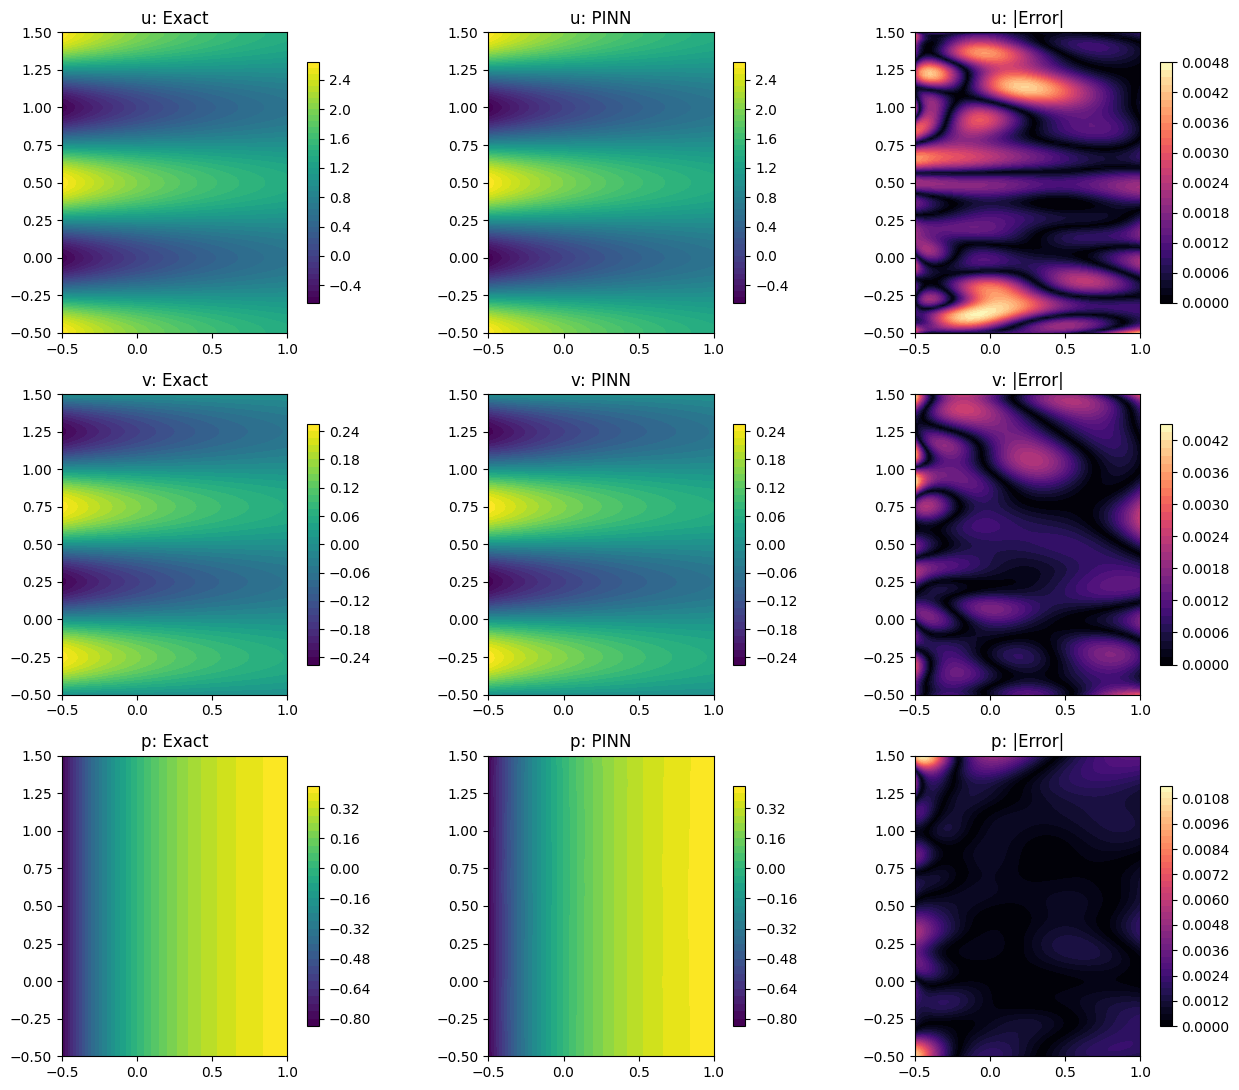

max abs error (u,v,p): ['4.72e-03', '4.39e-03', '1.12e-02']


In [6]:
import os
os.makedirs('figures', exist_ok=True); os.makedirs('weights', exist_ok=True)

with torch.no_grad():
    up, vp, pp = m64(xg64, yg64)
ex = [ue64, ve64, pe64]; pr = [up, vp, pp]; names = ['u', 'v', 'p']
XGn, YGn = XG.cpu().numpy(), YG.cpu().numpy()
sh = lambda t: t.cpu().numpy().reshape(100, 100)

fig, ax = plt.subplots(3, 3, figsize=(13, 11))
for i in range(3):
    E, P = sh(ex[i]), sh(pr[i])
    lo, hi = E.min(), E.max()
    for j, (F, t) in enumerate([(E, 'Exact'), (P, 'PINN'), (abs(P - E), '|Error|')]):
        kw = dict(vmin=lo, vmax=hi) if j < 2 else {}
        c = ax[i, j].contourf(XGn, YGn, F, 40, cmap='viridis' if j < 2 else 'magma', **kw)
        ax[i, j].set_title(f"{names[i]}: {t}"); ax[i, j].set_aspect('equal')
        plt.colorbar(c, ax=ax[i, j], shrink=0.8)
plt.tight_layout()
plt.savefig('figures/kovasznay_fields.png', dpi=150)
plt.show()

torch.save(m64.state_dict(), 'weights/pinn_kovasznay_final.pt')
print("max abs error (u,v,p):",
      [f"{(pr[i]-ex[i]).abs().max().item():.2e}" for i in range(3)])

**Cell 7: cavity setup and Adam**

In [7]:
RE = 100.0
torch.manual_seed(0)
model = PINN(hidden=40, layers=6).to(dev)   # overwrites Kovasznay model (weights already saved)

# Ghia et al. Re=100 centerline data
gy = torch.tensor([1.0, .9766, .9688, .9609, .9531, .8516, .7344, .6172, .5,
                   .4531, .2813, .1719, .1016, .0703, .0625, .0547, 0.], device=dev).reshape(-1,1)
gu = torch.tensor([1.0, .84123, .78871, .73722, .68717, .23151, .00332, -.13641, -.20581,
                   -.21090, -.15662, -.10150, -.06434, -.04775, -.04192, -.03717, 0.], device=dev).reshape(-1,1)
gx = torch.tensor([1.0, .9688, .9609, .9531, .9453, .9063, .8594, .8047, .5,
                   .2344, .2266, .1563, .0938, .0781, .0703, .0625, 0.], device=dev).reshape(-1,1)
gv = torch.tensor([0.0, -.05906, -.07391, -.08864, -.10313, -.16914, -.22445, -.24533, .05454,
                   .17527, .17507, .16077, .12317, .10890, .10091, .09233, 0.], device=dev).reshape(-1,1)

def ghia_err():
    with torch.no_grad():
        u, _, _ = model(torch.full_like(gy, .5), gy)     # u on x=0.5
        _, v, _ = model(gx, torch.full_like(gx, .5))     # v on y=0.5
    eu, ev = (u - gu).abs(), (v - gv).abs()
    return eu.max().item(), ev.max().item(), eu.pow(2).mean().sqrt().item(), ev.pow(2).mean().sqrt().item()

# Points: 10k interior, 200 per wall
def rnd(n, a=0., b=1.): return torch.rand(n, 1, device=dev)*(b - a) + a
x_f, y_f = rnd(10000).requires_grad_(True), rnd(10000).requires_grad_(True)
n = 200
z, o = torch.zeros(n, 1, device=dev), torch.ones(n, 1, device=dev)
x_b = torch.cat([rnd(n), rnd(n), z, o])            # top, bottom, left, right
y_b = torch.cat([o, z, rnd(n), rnd(n)])
u_b = torch.cat([o, z, z, z])                      # lid moves at u=1
v_b = torch.zeros(4*n, 1, device=dev)

W_PDE, W_BC, W_P = 1.0, 10.0, 1.0
def losses():
    u, v, p = model(x_f, y_f)
    r_c, r_u, r_v = ns_residual(u, v, p, x_f, y_f)
    l_pde = (r_c**2).mean() + (r_u**2).mean() + (r_v**2).mean()
    ub, vb, _ = model(x_b, y_b)
    l_bc = ((ub - u_b)**2).mean() + ((vb - v_b)**2).mean()
    l_p = p.mean()**2                              # fixes the pressure constant
    return l_pde, l_bc, l_p

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sch = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9998)
hist_c = []
for it in range(15001):
    opt.zero_grad()
    l_pde, l_bc, l_p = losses()
    loss = W_PDE*l_pde + W_BC*l_bc + W_P*l_p
    loss.backward(); opt.step(); sch.step()
    hist_c.append([loss.item(), l_pde.item(), l_bc.item(), l_p.item()])
    if it % 1500 == 0:
        e = ghia_err()
        print(f"{it:5d} loss {loss.item():.2e} pde {l_pde.item():.2e} bc {l_bc.item():.2e} "
              f"Ghia max(u,v) {e[0]:.3f} {e[1]:.3f} rms {e[2]:.3f} {e[3]:.3f}")
model_c_adam = copy.deepcopy(model)

    0 loss 2.72e+00 pde 2.90e-01 bc 2.42e-01 Ghia max(u,v) 0.729 0.269 rms 0.378 0.132
 1500 loss 1.90e-01 pde 2.22e-02 bc 1.68e-02 Ghia max(u,v) 0.293 0.285 rms 0.163 0.134
 3000 loss 1.05e-01 pde 1.76e-02 bc 8.74e-03 Ghia max(u,v) 0.220 0.269 rms 0.120 0.127
 4500 loss 8.54e-02 pde 1.68e-02 bc 6.86e-03 Ghia max(u,v) 0.221 0.263 rms 0.112 0.123
 6000 loss 6.50e-02 pde 1.41e-02 bc 5.09e-03 Ghia max(u,v) 0.181 0.236 rms 0.099 0.113
 7500 loss 4.23e-02 pde 9.48e-03 bc 3.28e-03 Ghia max(u,v) 0.128 0.173 rms 0.074 0.080
 9000 loss 2.89e-02 pde 5.74e-03 bc 2.31e-03 Ghia max(u,v) 0.096 0.118 rms 0.053 0.058
10500 loss 2.20e-02 pde 3.95e-03 bc 1.80e-03 Ghia max(u,v) 0.079 0.104 rms 0.043 0.051
12000 loss 1.83e-02 pde 3.22e-03 bc 1.50e-03 Ghia max(u,v) 0.067 0.092 rms 0.038 0.045
13500 loss 1.57e-02 pde 2.76e-03 bc 1.29e-03 Ghia max(u,v) 0.061 0.084 rms 0.036 0.041
15000 loss 1.37e-02 pde 2.41e-03 bc 1.13e-03 Ghia max(u,v) 0.056 0.079 rms 0.034 0.038


**Cell 8: continue Adam, then float64 L-BFGS**

In [8]:
# 1) Continue Adam: fresh optimizer, smaller lr
opt = torch.optim.Adam(model.parameters(), lr=5e-4)
sch = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9998)
for it in range(15001):
    opt.zero_grad()
    l_pde, l_bc, l_p = losses()
    loss = W_PDE*l_pde + W_BC*l_bc + W_P*l_p
    loss.backward(); opt.step(); sch.step()
    hist_c.append([loss.item(), l_pde.item(), l_bc.item(), l_p.item()])
    if it % 3000 == 0:
        e = ghia_err()
        print(f"{it:5d} loss {loss.item():.2e} pde {l_pde.item():.2e} bc {l_bc.item():.2e} "
              f"Ghia max(u,v) {e[0]:.3f} {e[1]:.3f} rms {e[2]:.3f} {e[3]:.3f}")
model_c_adam2 = copy.deepcopy(model)

# 2) float64 L-BFGS
m64 = copy.deepcopy(model).double()
d = lambda t: t.detach().double()
xf, yf = d(x_f).requires_grad_(True), d(y_f).requires_grad_(True)
xb, yb, ub, vb = d(x_b), d(y_b), d(u_b), d(v_b)
gy64, gu64, gx64, gv64 = d(gy), d(gu), d(gx), d(gv)

def parts64():
    u, v, p = m64(xf, yf)
    r_c, r_u, r_v = ns_residual(u, v, p, xf, yf)
    l_pde = (r_c**2).mean() + (r_u**2).mean() + (r_v**2).mean()
    up, vp, _ = m64(xb, yb)
    l_bc = ((up - ub)**2).mean() + ((vp - vb)**2).mean()
    return l_pde, l_bc, p.mean()**2

def ghia64():
    with torch.no_grad():
        u, _, _ = m64(torch.full_like(gy64, .5), gy64)
        _, v, _ = m64(gx64, torch.full_like(gx64, .5))
    eu, ev = (u - gu64).abs(), (v - gv64).abs()
    return [f"{eu.max().item():.3f}", f"{ev.max().item():.3f}",
            f"{eu.pow(2).mean().sqrt().item():.3f}", f"{ev.pow(2).mean().sqrt().item():.3f}"]

print("before L-BFGS Ghia max(u,v) rms(u,v):", ghia64())
opt4 = torch.optim.LBFGS(m64.parameters(), lr=1, max_iter=500, history_size=50,
                         tolerance_grad=1e-12, tolerance_change=1e-14,
                         line_search_fn='strong_wolfe')
def closure4():
    opt4.zero_grad()
    a, b, c = parts64()
    loss = W_PDE*a + W_BC*b + W_P*c
    loss.backward()
    return loss
opt4.step(closure4)
st = opt4.state[opt4._params[0]]
print("L-BFGS n_iter", st['n_iter'], "func_evals", st['func_evals'])
a, b, c = parts64()
print(f"pde {a.item():.2e} bc {b.item():.2e} p {c.item():.2e}")
print("after L-BFGS Ghia max(u,v) rms(u,v):", ghia64())

    0 loss 1.37e-02 pde 2.41e-03 bc 1.13e-03 Ghia max(u,v) 0.350 0.094 rms 0.196 0.065
 3000 loss 1.18e-02 pde 2.10e-03 bc 9.67e-04 Ghia max(u,v) 0.053 0.073 rms 0.032 0.035
 6000 loss 9.71e-03 pde 1.74e-03 bc 7.97e-04 Ghia max(u,v) 0.047 0.067 rms 0.029 0.032
 9000 loss 8.23e-03 pde 1.42e-03 bc 6.81e-04 Ghia max(u,v) 0.044 0.064 rms 0.027 0.030
12000 loss 7.00e-03 pde 1.17e-03 bc 5.83e-04 Ghia max(u,v) 0.043 0.062 rms 0.026 0.029
15000 loss 5.96e-03 pde 9.86e-04 bc 4.97e-04 Ghia max(u,v) 0.041 0.058 rms 0.025 0.028
before L-BFGS Ghia max(u,v) rms(u,v): ['0.041', '0.058', '0.025', '0.028']
L-BFGS n_iter 500 func_evals 543
pde 1.06e-03 bc 2.69e-04 p 2.63e-07
after L-BFGS Ghia max(u,v) rms(u,v): ['0.040', '0.053', '0.022', '0.027']


**Cell 9: where is the error?**

In [9]:
n = 200
with torch.no_grad():
    up, vp, _ = m64(xb, yb)
e_bc = ((up - ub)**2 + (vp - vb)**2).flatten()
for k, name in enumerate(['top(lid)', 'bottom', 'left', 'right']):
    print(f"{name:9s} bc MSE {e_bc[k*n:(k+1)*n].mean().item():.2e}")

# PDE residual on a fresh grid, corners vs rest
s = torch.linspace(0.01, 0.99, 80, dtype=torch.float64, device=dev)
XX, YY = torch.meshgrid(s, s, indexing='xy')
xr, yr = XX.reshape(-1, 1).clone().requires_grad_(True), YY.reshape(-1, 1).clone().requires_grad_(True)
u, v, p = m64(xr, yr)
rc, ru, rv = ns_residual(u, v, p, xr, yr)
r = (rc**2 + ru**2 + rv**2).sqrt().detach().flatten()
xn, yn = xr.detach().flatten(), yr.detach().flatten()
corner = (yn > 0.9) & ((xn < 0.1) | (xn > 0.9))
print(f"mean |residual|: lid corners {r[corner].mean().item():.3f}  rest {r[~corner].mean().item():.3f}")

# Worst Ghia points
with torch.no_grad():
    u_c, _, _ = m64(torch.full_like(gy64, .5), gy64)
    _, v_c, _ = m64(gx64, torch.full_like(gx64, .5))
eu, ev = (u_c - gu64).flatten(), (v_c - gv64).flatten()
for name, err, pos in [('u', eu, gy64), ('v', ev, gx64)]:
    idx = err.abs().argsort(descending=True)[:3]
    print(name, "worst:", [f"at {pos[i].item():.3f}: {err[i].item():+.3f}" for i in idx])

top(lid)  bc MSE 5.64e-04
bottom    bc MSE 1.60e-05
left      bc MSE 4.07e-04
right     bc MSE 9.06e-05
mean |residual|: lid corners 0.131  rest 0.022
u worst: ['at 0.281: +0.040', 'at 0.172: +0.038', 'at 0.734: -0.036']
v worst: ['at 0.805: +0.053', 'at 0.859: +0.046', 'at 0.156: -0.034']


**Cell 10: is the lid under-driven, and is the vortex uniformly weak?**

In [10]:
n = 200
with torch.no_grad():
    up, vp, _ = m64(xb, yb)

# 1) Lid: signed u - 1
xl = xb[:n].flatten(); du = up[:n].flatten() - 1
mid = (xl > 0.1) & (xl < 0.9)
print(f"lid u-1: centre mean {du[mid].mean().item():+.4f} | near corners mean {du[~mid].mean().item():+.4f}")

# 2) Left wall: error near the lid corner vs lower down
yl = yb[2*n:3*n].flatten()
el = ((up[2*n:3*n].flatten())**2 + (vp[2*n:3*n].flatten())**2)
top = yl > 0.9
print(f"left wall MSE: y>0.9 {el[top].mean().item():.2e} | y<=0.9 {el[~top].mean().item():.2e}")

# 3) Vortex strength: PINN / Ghia on centerline points with |Ghia| > 0.05
with torch.no_grad():
    u_c, _, _ = m64(torch.full_like(gy64, .5), gy64)
    _, v_c, _ = m64(gx64, torch.full_like(gx64, .5))
for name, pr, gh in [('u', u_c.flatten(), gu64.flatten()), ('v', v_c.flatten(), gv64.flatten())]:
    m = gh.abs() > 0.05
    ratio = (pr[m] / gh[m])
    print(f"{name} PINN/Ghia: median {ratio.median().item():.3f}, min {ratio.min().item():.3f}, max {ratio.max().item():.3f}")

lid u-1: centre mean -0.0001 | near corners mean -0.0084
left wall MSE: y>0.9 3.95e-03 | y<=0.9 1.29e-05
u PINN/Ghia: median 0.921, min 0.548, max 1.117
v PINN/Ghia: median 0.810, min 0.747, max 0.856


**Cell 11: corner refinement test**

In [11]:
mf = copy.deepcopy(m64).float()
k, kc = 100, 1500
rf = lambda n, a, b: torch.rand(n, 1, device=dev)*(b - a) + a
o1, z1 = (lambda m: torch.ones(m, 1, device=dev)), (lambda m: torch.zeros(m, 1, device=dev))

# extra boundary points near the lid corners
xb2 = torch.cat([x_b, rf(k, 0, .1), rf(k, .9, 1), z1(k), o1(k)])
yb2 = torch.cat([y_b, o1(k), o1(k), rf(k, .9, 1), rf(k, .9, 1)])
ub2 = torch.cat([u_b, o1(2*k), z1(2*k)])
vb2 = torch.zeros(len(xb2), 1, device=dev)
# extra interior points in the two corner boxes
xf2 = torch.cat([x_f.detach(), rf(kc, 0, .15), rf(kc, .85, 1)]).requires_grad_(True)
yf2 = torch.cat([y_f.detach(), rf(2*kc, .85, 1)]).requires_grad_(True)

def losses2():
    u, v, p = mf(xf2, yf2)
    r_c, r_u, r_v = ns_residual(u, v, p, xf2, yf2)
    l_pde = (r_c**2).mean() + (r_u**2).mean() + (r_v**2).mean()
    ub_, vb_, _ = mf(xb2, yb2)
    l_bc = ((ub_ - ub2)**2).mean() + ((vb_ - vb2)**2).mean()
    return l_pde, l_bc, p.mean()**2

def ghia_of(m):
    with torch.no_grad():
        u, _, _ = m(torch.full_like(gy, .5), gy)
        _, v, _ = m(gx, torch.full_like(gx, .5))
    eu, ev = (u - gu).abs(), (v - gv).abs()
    mk = gv.abs() > 0.05
    return (eu.max().item(), ev.max().item(), eu.pow(2).mean().sqrt().item(),
            ev.pow(2).mean().sqrt().item(), (v[mk]/gv[mk]).median().item())

print("start  Ghia max(u,v) rms(u,v) v-ratio:", [f"{e:.3f}" for e in ghia_of(mf)])
opt = torch.optim.Adam(mf.parameters(), lr=2e-4)
for it in range(4001):
    opt.zero_grad()
    l_pde, l_bc, l_p = losses2()
    loss = W_PDE*l_pde + W_BC*l_bc + W_P*l_p
    loss.backward(); opt.step()
    if it % 1000 == 0:
        print(f"{it:5d} loss {loss.item():.2e} pde {l_pde.item():.2e} bc {l_bc.item():.2e} "
              f"Ghia {[f'{e:.3f}' for e in ghia_of(mf)]}")

start  Ghia max(u,v) rms(u,v) v-ratio: ['0.040', '0.053', '0.022', '0.027', '0.810']
    0 loss 1.92e+01 pde 1.91e+01 bc 3.53e-03 Ghia ['0.050', '0.071', '0.035', '0.030', '0.879']
 1000 loss 7.92e-02 pde 7.74e-03 bc 7.14e-03 Ghia ['0.032', '0.029', '0.017', '0.015', '0.892']
 2000 loss 6.14e-02 pde 6.22e-03 bc 5.52e-03 Ghia ['0.035', '0.039', '0.021', '0.021', '0.849']
 3000 loss 5.28e-02 pde 5.88e-03 bc 4.69e-03 Ghia ['0.044', '0.051', '0.024', '0.029', '0.805']
 4000 loss 4.52e-02 pde 5.40e-03 bc 3.98e-03 Ghia ['0.042', '0.050', '0.023', '0.028', '0.807']


**Cell 12: loss weighting test**

In [12]:
mf = copy.deepcopy(m64).float()        # restart from float64 L-BFGS result
W_BC2 = 1.0

def losses3(m):
    u, v, p = m(x_f, y_f)
    r_c, r_u, r_v = ns_residual(u, v, p, x_f, y_f)
    l_pde = (r_c**2).mean() + (r_u**2).mean() + (r_v**2).mean()
    ub_, vb_, _ = m(x_b, y_b)
    l_bc = ((ub_ - u_b)**2).mean() + ((vb_ - v_b)**2).mean()
    return l_pde, l_bc, p.mean()**2

def report(it):
    e = ghia_of(mf)
    with torch.no_grad():
        ul, _, _ = mf(x_b[:200], y_b[:200])
    mid = (x_b[:200] > 0.1) & (x_b[:200] < 0.9)
    lid = (ul[mid] - 1).mean().item()
    print(f"{it:5d} pde {l_pde.item():.2e} bc {l_bc.item():.2e} | Ghia max(u,v) "
          f"{e[0]:.3f} {e[1]:.3f} rms {e[2]:.3f} {e[3]:.3f} v-ratio {e[4]:.3f} | lid centre {lid:+.4f}")

opt = torch.optim.Adam(mf.parameters(), lr=2e-4)
for it in range(6001):
    opt.zero_grad()
    l_pde, l_bc, l_p = losses3(mf)
    loss = W_PDE*l_pde + W_BC2*l_bc + W_P*l_p
    loss.backward(); opt.step()
    if it % 1500 == 0: report(it)

    0 pde 1.06e-03 bc 2.69e-04 | Ghia max(u,v) 0.044 0.093 rms 0.021 0.041 v-ratio 0.979 | lid centre -0.0030
 1500 pde 6.29e-04 bc 3.42e-04 | Ghia max(u,v) 0.039 0.055 rms 0.022 0.027 v-ratio 0.784 | lid centre -0.0042
 3000 pde 4.19e-04 bc 3.43e-04 | Ghia max(u,v) 0.037 0.054 rms 0.021 0.026 v-ratio 0.794 | lid centre -0.0024
 4500 pde 3.16e-04 bc 3.59e-04 | Ghia max(u,v) 0.036 0.051 rms 0.021 0.025 v-ratio 0.804 | lid centre -0.0009
 6000 pde 3.33e-04 bc 3.62e-04 | Ghia max(u,v) 0.034 0.049 rms 0.020 0.024 v-ratio 0.811 | lid centre -0.0004


**Cell 13: cavity figures and saved weights**

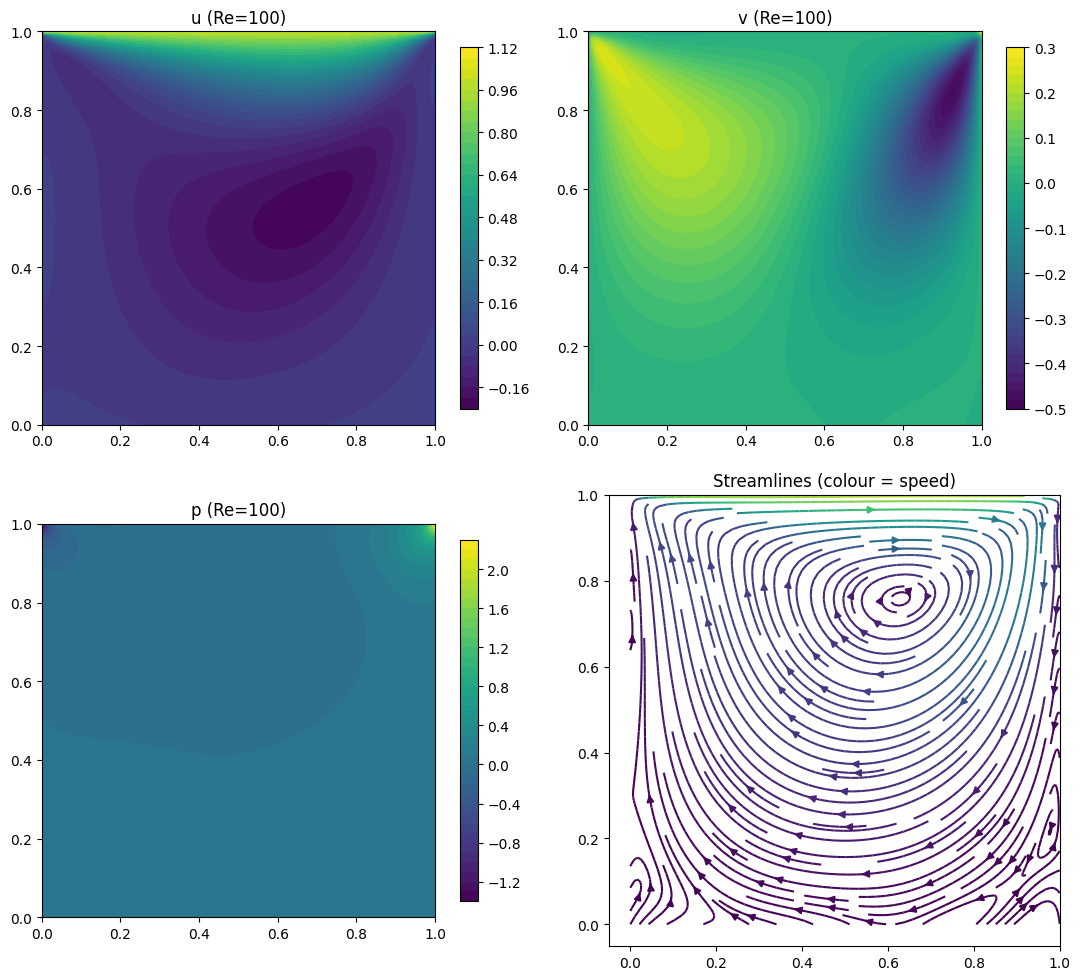

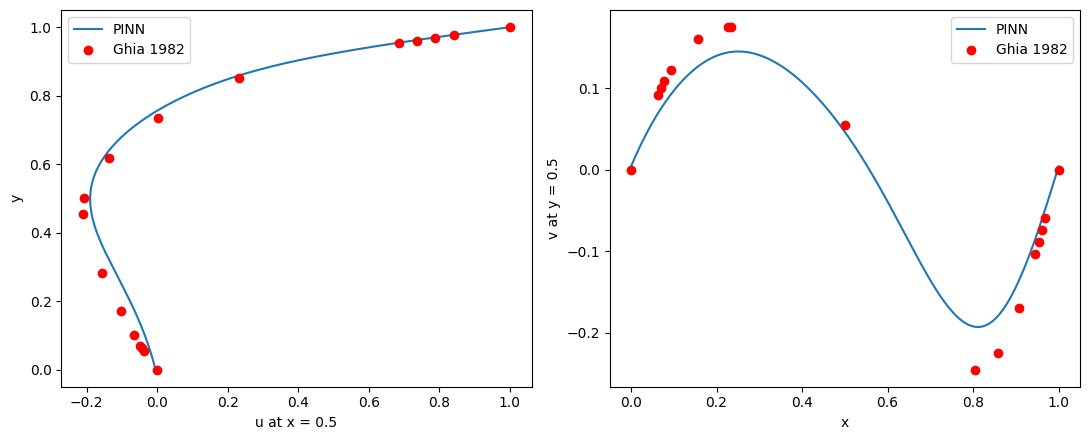

saved. min/max p: -1.3496699000309347 2.2265897278991518


In [13]:
s = torch.linspace(0, 1, 100, dtype=torch.float64, device=dev)
XX, YY = torch.meshgrid(s, s, indexing='xy')
with torch.no_grad():
    U, V, P = m64(XX.reshape(-1, 1), YY.reshape(-1, 1))
sh = lambda t: t.cpu().numpy().reshape(100, 100)
U, V, P = sh(U), sh(V), sh(P)
xn = s.cpu().numpy()

fig, ax = plt.subplots(2, 2, figsize=(11, 10))
for a, F, t in [(ax[0,0], U, 'u'), (ax[0,1], V, 'v'), (ax[1,0], P, 'p')]:
    c = a.contourf(xn, xn, F, 40, cmap='viridis')
    a.set_title(f"{t} (Re=100)"); a.set_aspect('equal'); plt.colorbar(c, ax=a, shrink=0.8)
a = ax[1,1]
a.streamplot(xn, xn, U, V, density=1.6, color=np.sqrt(U**2 + V**2), cmap='viridis')
a.set_title('Streamlines (colour = speed)'); a.set_aspect('equal')
plt.tight_layout(); plt.savefig('figures/cavity_fields.png', dpi=150); plt.show()

# Centerlines vs Ghia
yy = torch.linspace(0, 1, 200, dtype=torch.float64, device=dev).reshape(-1, 1)
with torch.no_grad():
    uc, _, _ = m64(torch.full_like(yy, .5), yy)
    _, vc, _ = m64(yy, torch.full_like(yy, .5))
n_ = lambda t: t.cpu().numpy()
fig2, b = plt.subplots(1, 2, figsize=(11, 4.5))
b[0].plot(n_(uc), n_(yy), label='PINN'); b[0].plot(n_(gu), n_(gy), 'ro', label='Ghia 1982')
b[0].set_xlabel('u at x = 0.5'); b[0].set_ylabel('y'); b[0].legend()
b[1].plot(n_(yy), n_(vc), label='PINN'); b[1].plot(n_(gx), n_(gv), 'ro', label='Ghia 1982')
b[1].set_xlabel('x'); b[1].set_ylabel('v at y = 0.5'); b[1].legend()
plt.tight_layout(); plt.savefig('figures/cavity_ghia.png', dpi=150); plt.show()

torch.save(m64.state_dict(), 'weights/pinn_cavity_final.pt')
print("saved. min/max p:", P.min().item(), P.max().item())

max u 1.101 at x=0.01, y=1.00
fraction of grid with u > 1.01: 0.0002


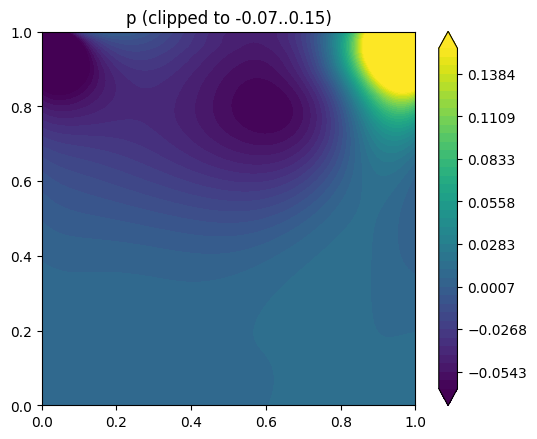

In [14]:
i = np.unravel_index(U.argmax(), U.shape)        # U is [y, x]
print(f"max u {U.max():.3f} at x={xn[i[1]]:.2f}, y={xn[i[0]]:.2f}")
print("fraction of grid with u > 1.01:", f"{(U > 1.01).mean():.4f}")

lo, hi = np.percentile(P, [2, 98])
fig, a = plt.subplots(figsize=(5.5, 5))
c = a.contourf(xn, xn, P, levels=np.linspace(lo, hi, 41), cmap='viridis', extend='both')
a.set_title(f"p (clipped to {lo:.2f}..{hi:.2f})"); a.set_aspect('equal')
plt.colorbar(c, ax=a, shrink=0.8)
plt.tight_layout(); plt.savefig('figures/cavity_pressure_clipped.png', dpi=150); plt.show()